# Laptop Price Prediction

<img src="https://bluetowertech.com/wp-content/uploads/2023/03/best-laptop-medium.jpg" alt="Laptop Görseli">

#### import the necessary packages

In [174]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

#### import data

In [5]:
df=pd.read_csv("laptop_data.csv")

#### EDA - Exploratory Data Analysis

In [7]:
df.head(10)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
5,5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000
6,6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016
7,7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360
8,8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000
9,9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000


In [8]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [9]:
df.drop(columns=["Unnamed: 0","OpSys","Weight" ],inplace=True) # Gereksiz sütunları kaldırıyoruz

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   object 
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   Price             1303 non-null   float64
dtypes: float64(2), object(7)
memory usage: 91.7+ KB


In [11]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
Price               0
dtype: int64

In [12]:
df.shape

(1303, 9)

In [13]:
df.sample(15)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,Price
986,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,1TB HDD,Intel HD Graphics 620,42943.6800
404,MSI,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,119826.7200
1211,Asus,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,93186.7200
809,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,1TB HDD,Nvidia GeForce 920M,32447.5200
501,HP,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,AMD Radeon 520,32979.7872
803,Dell,Notebook,15.6,4K Ultra HD / Touchscreen 3840x2160,Intel Core i5 7300HQ 2.5GHz,8GB,256GB SSD,Nvidia GeForce GTX 1050,93186.7200
458,Microsoft,Ultrabook,13.5,Touchscreen 2256x1504,Intel Core i7 7660U 2.5GHz,8GB,256GB SSD,Intel Iris Plus Graphics 640,95850.7200
339,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Nvidia GeForce 940MX,60885.7200
158,Dell,2 in 1 Convertible,15.6,Full HD / Touchscreen 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,256GB SSD,Intel UHD Graphics 620,55890.7200
1009,HP,Notebook,14.0,1366x768,Intel Core i3 7100U 2.4GHz,4GB,500GB HDD,Intel HD Graphics 620,36443.5200


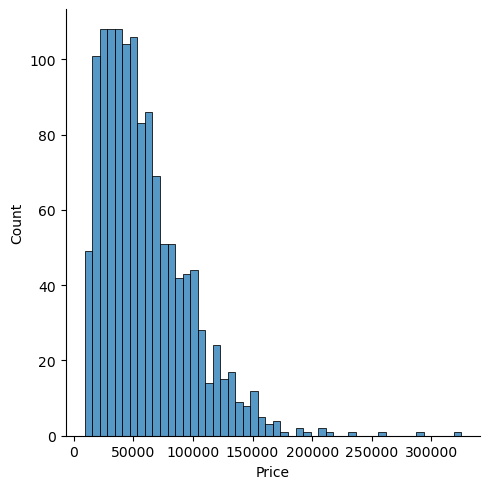

In [14]:
sns.displot(df["Price"], bins=50)

<Axes: xlabel='Company'>

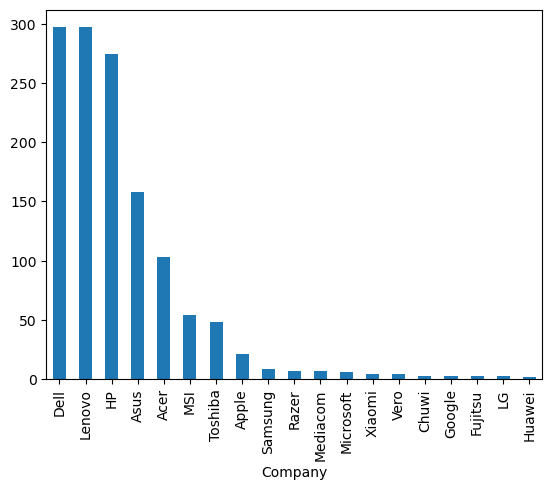

In [15]:
df["Company"].value_counts().plot(kind="bar")

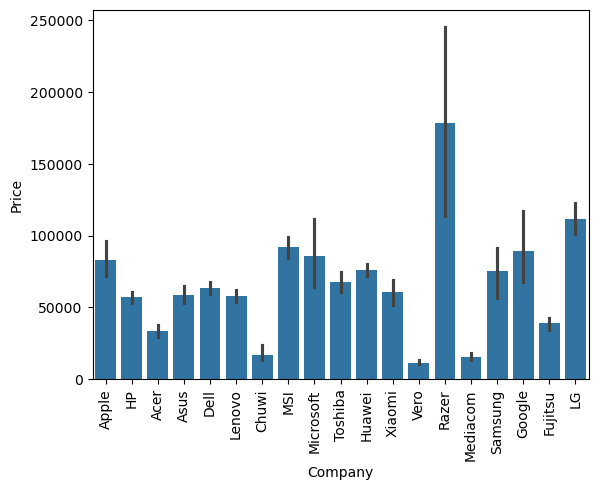

In [16]:
sns.barplot(x=df["Company"],y=df["Price"])
plt.xticks(rotation="vertical")
plt.show()

<Axes: xlabel='TypeName'>

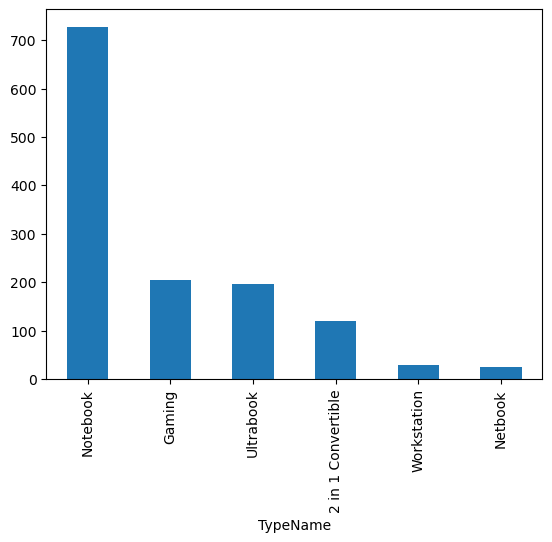

In [17]:
df["TypeName"].value_counts().plot(kind="bar")

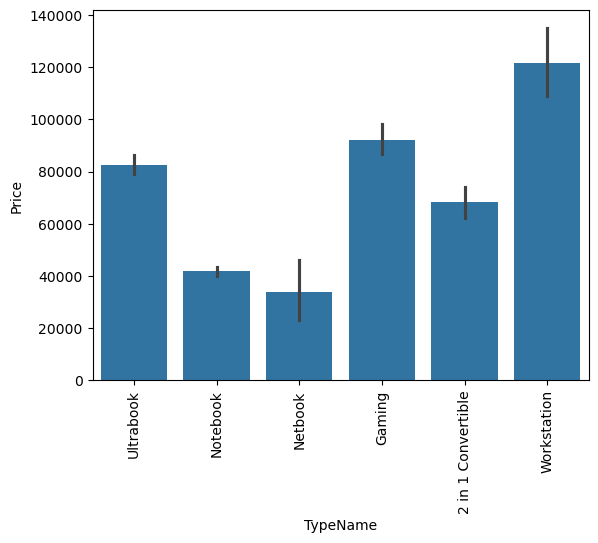

In [18]:
sns.barplot(x=df["TypeName"],y=df["Price"])
plt.xticks(rotation="vertical")
plt.show()

<Axes: >

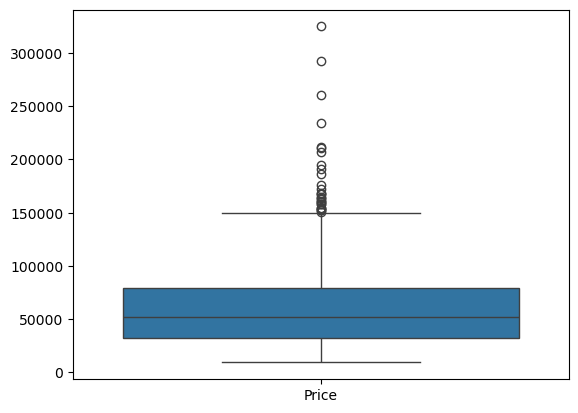

In [19]:
sns.boxplot([df["Price"]])

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Inches,1303.0,15.017191,1.426304,10.10,14.00,15.60,15.6000,18.40
Price,1303.0,59870.042910,37243.201786,9270.72,31914.72,52054.56,79274.2464,324954.72


In [21]:
# Ram'deki GB'ı kaldırıp int'e çeviriyoruz
df["Ram"] = df ["Ram"].str.replace("GB", "").astype(int)

In [22]:
# Bellek türlerini ayıralım
df["SSD"] = df["Memory"].apply(lambda x: int(float(x.split()[0].replace("GB","").replace("TB", "000"))) if "SSD" in x else 0)
df["HDD"] = df["Memory"].apply(lambda x: int(float(x.split()[0].replace("GB","").replace("TB", "000"))) if "HDD" in x else 0)
df["Other_Memory"] = df["Memory"].apply(lambda x: int(float(x.split()[0].replace("GB","").replace("TB", "000"))) if "SSD" not in x and "HDD" not in x else 0)

In [23]:
# Orjinal memory sütununu siliyoruz
df.drop(columns=["Memory"], inplace=True)

In [24]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Gpu,Price,SSD,HDD,Other_Memory
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,Intel Iris Plus Graphics 640,71378.6832,128,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,Intel HD Graphics 6000,47895.5232,0,0,128
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,Intel HD Graphics 620,30636.0000,256,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,AMD Radeon Pro 455,135195.3360,512,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,Intel Iris Plus Graphics 650,96095.8080,256,0,0


In [25]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Gpu                 0
Price               0
SSD                 0
HDD                 0
Other_Memory        0
dtype: int64

In [26]:
#İşlemci modeli
df["Cpu_Model"] = df["Cpu"].apply(lambda x: x.split()[0])

In [27]:
# İşlemci Türü
df["Cpu_Type"] = df["Cpu"].apply(lambda x: x.split()[1] if "Core" in x else x.split()[1] + " " + x.split()[2])

In [28]:
# İşlemci serisi
df["Cpu_Series"]= df["Cpu"].apply(lambda x: next((p for p in x.split() if p.startswith("i") and len(p) == 2), "Other"))

In [29]:
# İşlemci Nesil Bilgisini 
def extract_generation(cpu):
    parts = cpu.split()
    
    if "Intel" in cpu:
        for part in parts:
            if part.startswith("i") and len(part) == 2:  
                idx = parts.index(part) + 1 
                if idx < len(parts) and parts[idx][0].isdigit():  
                    generation = parts[idx][0]  # İlk rakam nesildir
                    if generation in "123456789":  
                        return generation
        return "1"  # Geçerli bir nesil bulunamazsa 1 olarak işlenir
    
    elif "AMD" in cpu:
        if "Ryzen" in cpu:
            for part in parts:
                if part.isdigit() and len(part) >= 4:  # Ryzen 1600, 2600, 3700X gibi modeller
                    return part[0]  # İlk rakam nesil bilgisidir (1, 2, 3, 4 vb.)
        return "1"  # E-Series, FX, Athlon gibi eski AMD modelleri için varsayılan olarak 1
    
    return "1"  # Diğer tüm işlemciler için varsayılan olarak 1

df["Cpu_Generation"] = df["Cpu"].apply(extract_generation)

In [30]:
# GHz Değerini Çıkartalım
df["Cpu_GHz"] = df["Cpu"].apply(lambda x: float(x.split()[-1].replace("GHz", "")))

In [31]:
# Orijinal CPU sütununu kaldır
df.drop(columns=["Cpu"], inplace=True)

In [32]:
df["Gpu"].unique

<bound method Series.unique of 0       Intel Iris Plus Graphics 640
1             Intel HD Graphics 6000
2              Intel HD Graphics 620
3                 AMD Radeon Pro 455
4       Intel Iris Plus Graphics 650
                    ...             
1298           Intel HD Graphics 520
1299           Intel HD Graphics 520
1300               Intel HD Graphics
1301              AMD Radeon R5 M330
1302               Intel HD Graphics
Name: Gpu, Length: 1303, dtype: object>

In [33]:
# GPU Markası
df["Gpu_Brand"] = df["Gpu"].apply(lambda x: x.split()[0])

In [34]:
df["Gpu_Series"] = df["Gpu"].apply(lambda x: x.split()[1] if len(x.split()) > 1 else "Unknown")


In [35]:
df.sample(14)

,Company,TypeName,Inches,ScreenResolution,Ram,Gpu,Price,SSD,HDD,Other_Memory,Cpu_Model,Cpu_Type,Cpu_Series,Cpu_Generation,Cpu_GHz,Gpu_Brand,Gpu_Series
568,Lenovo,Notebook,15.6,Full HD 1920x1080,4,Intel HD Graphics 505,18328.32,0,500,0,Intel,Pentium,Other,1,1.1,Intel,HD
557,Lenovo,Notebook,17.3,1600x900,6,Nvidia GeForce 940MX,50562.72,128,128,0,Intel,Core,i7,7,2.7,Nvidia,GeForce
250,Dell,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,8,Intel UHD Graphics 620,43636.32,0,1000,0,Intel,Core,i7,8,1.8,Intel,UHD
512,Dell,Notebook,15.6,Full HD 1920x1080,8,Intel HD Graphics 620,44542.08,0,1000,0,Intel,Core,i5,7,2.5,Intel,HD
70,Microsoft,Ultrabook,13.5,Touchscreen 2256x1504,4,Intel HD Graphics 620,58021.92,128,0,0,Intel,Core,i5,7,2.5,Intel,HD
608,Lenovo,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,8,Intel HD Graphics 630,69210.72,256,0,0,Intel,Core,i7,7,2.8,Intel,HD
865,HP,Notebook,15.6,Full HD 1920x1080,4,Intel HD Graphics 520,48484.80,0,500,0,Intel,Core,i5,6,2.3,Intel,HD
1031,Acer,Notebook,15.6,1366x768,6,AMD Radeon R5,21791.52,0,1000,0,AMD,A9-Series 9420,Other,1,3.0,AMD,Radeon
717,Lenovo,Notebook,15.6,1366x768,4,AMD Radeon R4,15877.44,0,500,0,AMD,A6-Series 7310,Other,1,2.0,AMD,Radeon
321,Lenovo,Notebook,17.3,1600x900,4,Nvidia GeForce 920MX,31381.92,0,1000,0,Intel,Core,i5,7,2.5,Nvidia,GeForce


In [36]:
# GPU Model
df["Gpu_Model"] = df["Gpu"].apply(lambda x: " ".join(x.split()[2:]) if len(x.split()) > 2 else "Unkown")

In [37]:
df["Gpu_Type"] = df["Gpu"].apply(lambda x: "Integrated" if "Intel" in x else "Dedicated")

In [38]:
# Orijinal GPU sütununu kaldırıyoruz
df.drop(columns=["Gpu"], inplace=True)

In [39]:
df

,Company,TypeName,Inches,ScreenResolution,Ram,Price,SSD,HDD,Other_Memory,Cpu_Model,Cpu_Type,Cpu_Series,Cpu_Generation,Cpu_GHz,Gpu_Brand,Gpu_Series,Gpu_Model,Gpu_Type
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,71378.6832,128,0,0,Intel,Core,i5,2,2.3,Intel,Iris,Plus Graphics 640,Integrated
1,Apple,Ultrabook,13.3,1440x900,8,47895.5232,0,0,128,Intel,Core,i5,1,1.8,Intel,HD,Graphics 6000,Integrated
2,HP,Notebook,15.6,Full HD 1920x1080,8,30636.0000,256,0,0,Intel,Core,i5,7,2.5,Intel,HD,Graphics 620,Integrated
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,135195.3360,512,0,0,Intel,Core,i7,2,2.7,AMD,Radeon,Pro 455,Dedicated
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,96095.8080,256,0,0,Intel,Core,i5,3,3.1,Intel,Iris,Plus Graphics 650,Integrated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,4,33992.6400,128,0,0,Intel,Core,i7,6,2.5,Intel,HD,Graphics 520,Integrated
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,16,79866.7200,512,0,0,Intel,Core,i7,6,2.5,Intel,HD,Graphics 520,Integrated
1300,Lenovo,Notebook,14.0,1366x768,2,12201.1200,0,0,64,Intel,Celeron,Other,1,1.6,Intel,HD,Graphics,Integrated
1301,HP,Notebook,15.6,1366x768,6,40705.9200,0,1000,0,Intel,Core,i7,6,2.5,AMD,Radeon,R5 M330,Dedicated


In [40]:
df["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x14

In [41]:
# IPS ekran var mı? 
df["IPS"] = df["ScreenResolution"].apply(lambda x: 1 if "IPS" in x else 0)

In [42]:
# Dokunmatik ekran var mı?
df["TouchScreen"] = df["ScreenResolution"].apply(lambda x: 1 if "Touchscreen" in x else 0)

In [43]:
# Çözünürlüğü genişlik ve yükseklik olarak ayıralım
df["Resolution_Width"] = df["ScreenResolution"].apply(lambda x: int(x.split()[-1].split("x")[0]))
df["Resolution_Height"] = df["ScreenResolution"].apply(lambda x: int(x.split()[-1].split("x")[1]))

In [44]:
# Orijinal ScreenResolution sütununu silebiliriz
df.drop(columns=["ScreenResolution"], inplace=True)

In [45]:
df.sample(12)

,Company,TypeName,Inches,Ram,Price,SSD,HDD,Other_Memory,Cpu_Model,Cpu_Type,...,Cpu_Generation,Cpu_GHz,Gpu_Brand,Gpu_Series,Gpu_Model,Gpu_Type,IPS,TouchScreen,Resolution_Width,Resolution_Height
964,HP,Notebook,15.6,8,45101.520,0,1000,0,Intel,Core,...,7,2.5,Nvidia,GeForce,930MX,Dedicated,0,0,1366,768
199,HP,Notebook,17.3,8,55677.600,256,0,0,Intel,Core,...,8,1.8,Nvidia,GeForce,930MX,Dedicated,0,0,1920,1080
523,HP,Notebook,15.6,4,36709.920,128,0,0,Intel,Core,...,6,2.0,Intel,HD,Graphics 520,Integrated,0,0,1366,768
473,Dell,Ultrabook,13.3,8,98133.768,256,0,0,Intel,Core,...,8,1.6,Intel,UHD,Graphics 620,Integrated,0,1,1920,1080
23,Dell,2 in 1 Convertible,13.3,8,43636.320,256,0,0,Intel,Core,...,8,1.6,Intel,UHD,Graphics 620,Integrated,0,1,1920,1080
1259,MSI,Gaming,15.6,8,65481.120,128,128,0,Intel,Core,...,6,2.6,Nvidia,GeForce,GTX 960M,Dedicated,0,0,1920,1080
1088,HP,Notebook,13.3,4,32767.200,0,0,32,Intel,Pentium,...,1,1.5,Intel,HD,Graphics 515,Integrated,0,0,3200,1800
450,HP,Notebook,15.6,8,31381.920,128,0,0,Intel,Core,...,7,2.5,Intel,HD,Graphics 620,Integrated,0,0,1366,768
373,Lenovo,Notebook,17.3,4,26053.920,128,0,0,AMD,A8-Series 7410,...,1,2.2,AMD,Radeon,R5,Dedicated,0,0,1600,900
153,MSI,Gaming,17.3,16,100699.200,256,256,0,Intel,Core,...,7,2.8,Nvidia,GeForce,GTX 1060,Dedicated,0,0,1920,1080


In [46]:
df.isnull().sum()

Company              0
TypeName             0
Inches               0
Ram                  0
Price                0
SSD                  0
HDD                  0
Other_Memory         0
Cpu_Model            0
Cpu_Type             0
Cpu_Series           0
Cpu_Generation       0
Cpu_GHz              0
Gpu_Brand            0
Gpu_Series           0
Gpu_Model            0
Gpu_Type             0
IPS                  0
TouchScreen          0
Resolution_Width     0
Resolution_Height    0
dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            1303 non-null   object 
 1   TypeName           1303 non-null   object 
 2   Inches             1303 non-null   float64
 3   Ram                1303 non-null   int32  
 4   Price              1303 non-null   float64
 5   SSD                1303 non-null   int64  
 6   HDD                1303 non-null   int64  
 7   Other_Memory       1303 non-null   int64  
 8   Cpu_Model          1303 non-null   object 
 9   Cpu_Type           1303 non-null   object 
 10  Cpu_Series         1303 non-null   object 
 11  Cpu_Generation     1303 non-null   object 
 12  Cpu_GHz            1303 non-null   float64
 13  Gpu_Brand          1303 non-null   object 
 14  Gpu_Series         1303 non-null   object 
 15  Gpu_Model          1303 non-null   object 
 16  Gpu_Type           1303 

In [48]:
# Gpu_Type sütununu 0 ve 1 olarak dönüştürme
df["Gpu_Type"] = df["Gpu_Type"].map({"Dedicated": 1, "Integrated": 0})

In [49]:
df.sample(12)

,Company,TypeName,Inches,Ram,Price,SSD,HDD,Other_Memory,Cpu_Model,Cpu_Type,...,Cpu_Generation,Cpu_GHz,Gpu_Brand,Gpu_Series,Gpu_Model,Gpu_Type,IPS,TouchScreen,Resolution_Width,Resolution_Height
1032,MSI,Gaming,17.3,8,63499.1040,128,128,0,Intel,Core,...,7,2.80,Nvidia,GeForce,GTX 1050,1,0,0,1920,1080
305,Lenovo,Notebook,15.6,4,19180.2672,0,1000,0,Intel,Pentium,...,1,1.10,Intel,HD,Graphics 505,0,0,0,1366,768
909,LG,Ultrabook,14.0,8,101178.7200,512,0,0,Intel,Core,...,7,2.70,Intel,HD,Graphics 620,0,1,1,1920,1080
30,Chuwi,Notebook,15.6,4,13053.0672,0,0,64,Intel,Atom x5-Z8300,...,1,1.44,Intel,HD,Graphics,0,0,0,1920,1080
3,Apple,Ultrabook,15.4,16,135195.3360,512,0,0,Intel,Core,...,2,2.70,AMD,Radeon,Pro 455,1,1,0,2880,1800
754,Asus,Notebook,15.6,4,45282.6720,256,0,0,Intel,Core,...,7,2.70,Intel,HD,Graphics 620,0,0,0,1366,768
5,Acer,Notebook,15.6,4,21312.0000,0,500,0,AMD,A9-Series 9420,...,1,3.00,AMD,Radeon,R5,1,0,0,1366,768
460,Acer,Notebook,15.6,4,28984.3200,0,1000,0,Intel,Core,...,6,2.00,Nvidia,GeForce,940MX,1,0,0,1920,1080
607,Lenovo,Notebook,15.6,6,30049.9200,0,1000,0,Intel,Core,...,7,2.50,Intel,HD,Graphics 620,0,0,0,1920,1080
1208,Acer,Notebook,17.3,8,33513.1200,0,1000,0,Intel,Core,...,6,2.00,Nvidia,GeForce,940MX,1,0,0,1600,900


In [50]:
df.corr(numeric_only=True)

,Inches,Ram,Price,SSD,HDD,Other_Memory,Cpu_GHz,Gpu_Type,IPS,TouchScreen,Resolution_Width,Resolution_Height
Inches,1.000000,0.237993,0.068197,-0.108993,0.367278,-0.217854,0.307870,0.592264,-0.114804,-0.361735,-0.071245,-0.095404
Ram,0.237993,1.000000,0.743007,0.604344,-0.132952,-0.064738,0.368000,0.319551,0.206623,0.116984,0.433121,0.424437
Price,0.068197,0.743007,1.000000,0.676202,-0.302697,-0.040816,0.430293,0.184205,0.252208,0.191226,0.556529,0.552809
SSD,-0.108993,0.604344,0.676202,1.000000,-0.527178,-0.145747,0.261976,0.022848,0.227341,0.254263,0.533325,0.524574
HDD,0.367278,-0.132952,-0.302697,-0.527178,1.000000,-0.098500,0.000956,0.172836,-0.171883,-0.154381,-0.251442,-0.258011
Other_Memory,-0.217854,-0.064738,-0.040816,-0.145747,-0.098500,1.000000,-0.205697,-0.128834,0.056815,-0.021694,-0.027555,0.002278
Cpu_GHz,0.307870,0.368000,0.430293,0.261976,0.000956,-0.205697,1.000000,0.363658,0.063035,-0.082579,0.183548,0.169668
Gpu_Type,0.592264,0.319551,0.184205,0.022848,0.172836,-0.128834,0.363658,1.000000,0.045552,-0.255308,0.105671,0.091678
IPS,-0.114804,0.206623,0.252208,0.227341,-0.171883,0.056815,0.063035,0.045552,1.000000,0.150512,0.281457,0.289030
TouchScreen,-0.361735,0.116984,0.191226,0.254263,-0.154381,-0.021694,-0.082579,-0.255308,0.150512,1.000000,0.351066,0.357930


In [51]:
abs(df.corr(numeric_only=True)['Price']).sort_values(ascending=False)

Price                1.000000
Ram                  0.743007
SSD                  0.676202
Resolution_Width     0.556529
Resolution_Height    0.552809
Cpu_GHz              0.430293
HDD                  0.302697
IPS                  0.252208
TouchScreen          0.191226
Gpu_Type             0.184205
Inches               0.068197
Other_Memory         0.040816
Name: Price, dtype: float64

In [52]:
x=df.drop(["Price","Other_Memory","Gpu_Type","Inches","Gpu_Type"], axis=1)
y=df[["Price"]]

In [53]:
x=pd.get_dummies(x,drop_first=True)

#### Modelling

In [55]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.20, random_state=42)

In [56]:
#Linear Regression

In [57]:
lr=LinearRegression()

In [58]:
lr.fit(x_train,y_train)

LinearRegression()

In [59]:
pred_lr=lr.predict(x_test)

In [60]:
r2_score(y_test, pred_lr)

0.8129674813765484

In [61]:
mean_squared_error(y_test, pred_lr)**.5

16421.893215290213

In [62]:
#Decision Tree Regressor

In [63]:
dt = DecisionTreeRegressor()

In [64]:
dt.fit(x_train, y_train)

DecisionTreeRegressor()

In [65]:
pred_dt = dt.predict(x_test)

In [66]:
r2_score(y_test, pred_dt)

0.6808877464227778

In [67]:
mean_squared_error(y_test, pred_dt)**.5

21450.449785063924

In [68]:
# Random Forest

In [69]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [70]:
rf.fit(x_train, y_train)

C:\Users\OguzToy\anaconda3\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

In [71]:
pred_rf=rf.predict(x_test)

In [72]:
r2_score(y_test, pred_rf)

0.7813804008661414

In [73]:
mean_squared_error(y_test, pred_rf)**.5

17754.531201269237

In [74]:
#AdaBoost Regressor

In [75]:
ab = AdaBoostRegressor(n_estimators=50)

In [76]:
ab.fit(x_train,y_train)

C:\Users\OguzToy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


AdaBoostRegressor()

In [77]:
pred_ab=ab.predict(x_test)

In [78]:
r2_score(y_test, pred_ab)

0.6879957920940933

In [79]:
mean_squared_error(y_test, pred_ab)**.5

21210.20608559034

In [80]:
# XGBoost Regressor

In [81]:
xgb = XGBRegressor()

In [82]:
# XGBoost, özel karakterler ([, ] veya <) içeren sütun adlarını kabul etmiyor o yüzden düzenleme yapıyoruz.
x_train.columns = [f'feature_{i}' for i in range(x_train.shape[1])]
x_test.columns = [f'feature_{i}' for i in range(x_test.shape[1])]

In [83]:
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [84]:
pred_xgb = xgb.predict(x_test)

In [85]:
r2_score(y_test, pred_xgb)

0.8257219195365906

In [86]:
mean_squared_error(y_test, pred_xgb)**.5

15852.071765115063

####  GridSearchCV ile optimize

In [179]:
rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Ağaç sayısı
    'max_depth': [None, 10, 20],  # Maksimum derinlik
    'min_samples_split': [2, 5, 10],  # Minimum dallanma sayısı
    'min_samples_leaf': [1, 2, 4]  # Minimum yaprak örnek sayısı
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1, verbose=2)
grid_rf.fit(x_train, y_train)

print("Random Forest En İyi Parametreler:", grid_rf.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Random Forest En İyi Parametreler: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [181]:
ab = AdaBoostRegressor(random_state=42)

param_grid_ab = {
    'n_estimators': [50, 100, 200],  # Zayıf öğrenicilerin sayısı
    'learning_rate': [0.01, 0.1, 0.5, 1]  # Öğrenme oranı
}

grid_ab = GridSearchCV(ab, param_grid_ab, cv=5, scoring='r2', n_jobs=-1, verbose=2)
grid_ab.fit(x_train, y_train)

print("AdaBoost En İyi Parametreler:", grid_ab.best_params_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
AdaBoost En İyi Parametreler: {'learning_rate': 0.1, 'n_estimators': 100}


In [183]:
xgb = XGBRegressor(random_state=42)

param_grid_xgb = {
    'n_estimators': [50, 100, 200],  # Ağaç sayısı
    'learning_rate': [0.01, 0.1, 0.3],  # Öğrenme oranı
    'max_depth': [3, 5, 7]  # Maksimum derinlik
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='r2', n_jobs=-1, verbose=2)
grid_xgb.fit(x_train, y_train)

print("XGBoost En İyi Parametreler:", grid_xgb.best_params_)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
XGBoost En İyi Parametreler: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [189]:
# En iyi modelleri alalım
best_rf = grid_rf.best_estimator_
best_ab = grid_ab.best_estimator_
best_xgb = grid_xgb.best_estimator_

# Test setinde tahmin yapalım
pred_rf = best_rf.predict(x_test)
pred_ab = best_ab.predict(x_test)
pred_xgb = best_xgb.predict(x_test)

# Performans değerlendirme fonksiyonu
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} :")
    print(f"R² Score: {r2:.4f}")
    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")

# Modelleri değerlendirelim
evaluate_model(y_test, pred_rf, "Random Forest")
evaluate_model(y_test, pred_ab, "AdaBoost")
evaluate_model(y_test, pred_xgb, "XGBoost")



Random Forest :
R² Score: 0.7797
MSE: 317581480.85
MAE: 10877.22

AdaBoost :
R² Score: 0.7287
MSE: 391119589.50
MAE: 14902.25

XGBoost :
R² Score: 0.8264
MSE: 250241897.32
MAE: 9761.27
